## Data Leakage test 

### CV test vs 검증실험 비교

I0000 00:00:1785885980.171564  252149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785885980.357115  252149 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785885981.025315  252149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1785885981.292163  252149 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

=== CV Test vs Holdout Val ===
                                 CV Test (10-seed mean ± SD) Holdout Val (n=27)
Task             Metric                                                        
Classification   Accuracy                      0.857 ± 0.028              0.815
                 F1-macro                      0.848 ± 0.042              0.767
Regression (E2E) R²                            0.713 ± 0.036              0.757
                 MAE (log CFU/g)               0.433 ± 0.039              0.471

* Val set은 CLR fit / feature selection / labeling 결정에 일절 미관여
* CV Test ≈ Holdout Val → 파이프라인 leakage 없음을 지지


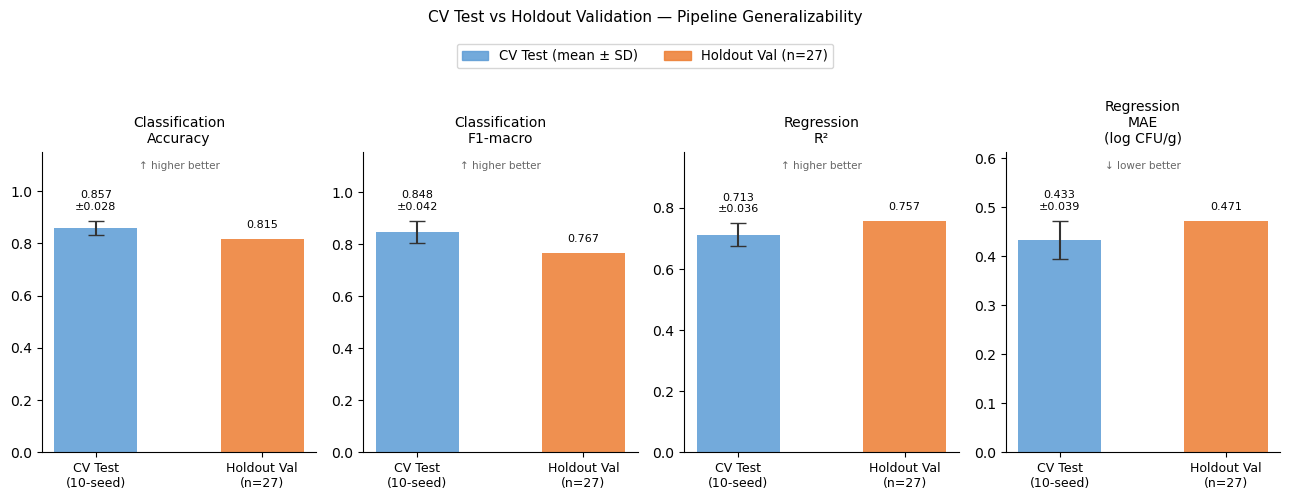

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures/val_cv_comparison.png


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import accuracy_score

PKL_DIR = "/home/admin-01/taeho/BRL_chicken/revision/code/data/pkl"
VAL_DIR = "/home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures"

# ── classification_results.pkl ────────────────────────────────────
with open(f"{PKL_DIR}/classification_results.pkl", 'rb') as f:
    clf_res = pickle.load(f)

_cond, _model = 'cond1', 'RandomForest'
_seeds = list(clf_res[_cond][_model].keys())
cv_clf_acc = np.mean([clf_res[_cond][_model][s]['test_acc'] for s in _seeds])
cv_clf_f1  = np.mean([clf_res[_cond][_model][s]['test_f1']  for s in _seeds])
cv_clf_acc_std = np.std([clf_res[_cond][_model][s]['test_acc'] for s in _seeds])
cv_clf_f1_std  = np.std([clf_res[_cond][_model][s]['test_f1']  for s in _seeds])

# ── regression_results.pkl (LSTMRegressor stub 필요) ──────────────
class _LSTMStub: pass
class _SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'LSTMRegressor': return _LSTMStub
        return super().find_class(module, name)

with open(f"{PKL_DIR}/regression_results.pkl", 'rb') as f:
    reg_res = _SafeUnpickler(f).load()

_cond_r, _model_r = 'cond1', 'RandomForest'
_seeds_r = list(reg_res[_cond_r][_model_r].keys())
cv_reg_r2  = np.mean([reg_res[_cond_r][_model_r][s]['test_r2']  for s in _seeds_r])
cv_reg_mae = np.mean([reg_res[_cond_r][_model_r][s]['test_mae'] for s in _seeds_r])
cv_reg_r2_std  = np.std([reg_res[_cond_r][_model_r][s]['test_r2']  for s in _seeds_r])
cv_reg_mae_std = np.std([reg_res[_cond_r][_model_r][s]['test_mae'] for s in _seeds_r])

# ── validation_results.pkl ────────────────────────────────────────
with open(f"{PKL_DIR}/validation_results.pkl", 'rb') as f:
    val_res = pickle.load(f)

# ── 비교 테이블 ────────────────────────────────────────────────────
rows = [
    {'Task': 'Classification', 'Metric': 'Accuracy',
     f'CV Test ({len(_seeds)}-seed mean ± SD)': f"{cv_clf_acc:.3f} ± {cv_clf_acc_std:.3f}",
     'Holdout Val (n=27)': f"{val_res['clf_acc']:.3f}"},
    {'Task': 'Classification', 'Metric': 'F1-macro',
     f'CV Test ({len(_seeds)}-seed mean ± SD)': f"{cv_clf_f1:.3f} ± {cv_clf_f1_std:.3f}",
     'Holdout Val (n=27)': f"{val_res['clf_f1']:.3f}"},
    {'Task': 'Regression (E2E)', 'Metric': 'R²',
     f'CV Test ({len(_seeds_r)}-seed mean ± SD)': f"{cv_reg_r2:.3f} ± {cv_reg_r2_std:.3f}",
     'Holdout Val (n=27)': f"{val_res['e2e_r2']:.3f}"},
    {'Task': 'Regression (E2E)', 'Metric': 'MAE (log CFU/g)',
     f'CV Test ({len(_seeds_r)}-seed mean ± SD)': f"{cv_reg_mae:.3f} ± {cv_reg_mae_std:.3f}",
     'Holdout Val (n=27)': f"{val_res['e2e_mae']:.3f}"},
]
cmp_df = pd.DataFrame(rows).set_index(['Task', 'Metric'])
print("=== CV Test vs Holdout Val ===")
print(cmp_df.to_string())
print()
print("* Val set은 CLR fit / feature selection / labeling 결정에 일절 미관여")
print("* CV Test ≈ Holdout Val → 파이프라인 leakage 없음을 지지")

# ── Figure: CV Test vs Holdout Val ────────────────────────────────
from matplotlib.patches import Patch

C_CV  = '#5B9BD5'
C_VAL = '#ED7D31'

metrics_info = [
    ('Classification', 'Accuracy',        cv_clf_acc,  cv_clf_acc_std,  val_res['clf_acc'],  '↑ higher better'),
    ('Classification', 'F1-macro',         cv_clf_f1,   cv_clf_f1_std,   val_res['clf_f1'],   '↑ higher better'),
    ('Regression',     'R²',              cv_reg_r2,   cv_reg_r2_std,   val_res['e2e_r2'],   '↑ higher better'),
    ('Regression',     'MAE\n(log CFU/g)', cv_reg_mae,  cv_reg_mae_std,  val_res['e2e_mae'],  '↓ lower better'),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))

for ax, (task, metric, cv_m, cv_s, val_v, direction) in zip(axes, metrics_info):
    ax.bar([0], [cv_m],  width=0.5, color=C_CV,  alpha=0.85, label='CV Test')
    ax.bar([1], [val_v], width=0.5, color=C_VAL, alpha=0.85, label='Holdout Val')
    ax.errorbar(0, cv_m, yerr=cv_s, fmt='none', color='#333333', capsize=6, lw=1.5)

    top_cv  = cv_m + cv_s
    top_val = val_v
    pad = max(top_cv, top_val) * 0.04
    ax.text(0, top_cv  + pad, f"{cv_m:.3f}\n±{cv_s:.3f}", ha='center', va='bottom', fontsize=8)
    ax.text(1, top_val + pad, f"{val_v:.3f}",             ha='center', va='bottom', fontsize=8)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['CV Test\n(10-seed)', 'Holdout Val\n(n=27)'], fontsize=9)
    ax.set_title(f"{task}\n{metric}", fontsize=10)
    ax.set_ylim(0, max(top_cv, top_val) * 1.30)
    ax.text(0.5, 0.97, direction, transform=ax.transAxes,
            ha='center', va='top', fontsize=7.5, color='#666666')
    ax.spines[['top', 'right']].set_visible(False)

handles = [Patch(color=C_CV,  alpha=0.85, label='CV Test (mean ± SD)'),
           Patch(color=C_VAL, alpha=0.85, label='Holdout Val (n=27)')]
fig.legend(handles=handles, loc='upper center', ncol=2,
           fontsize=9.5, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("CV Test vs Holdout Validation — Pipeline Generalizability",
             fontsize=11, y=1.10)
plt.tight_layout()
fig.savefig(f"{VAL_DIR}/val_cv_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VAL_DIR}/val_cv_comparison.png")

## Permutation test

## Permutation Test — Logical Distinction Between the Two Tests

This study performs two label permutation tests (Ojala & Garriga, 2010), each addressing a distinct question.

---

### Test 1: Standard permutation (fixed features)

**What it verifies**: "Model performance is not attributable to chance (random noise)"

Features are selected **once** from the full dataset and fixed; only the labels are randomly shuffled, and the same 5-fold CV is repeated 1,000 times.
If the observed model performance substantially exceeds the null distribution, the feature–label relationship is statistically significant.

> ⚠️ Limitation: This test demonstrates only that a relationship exists; it does not directly verify whether test-set information leaked into the feature selection process.

---

### Test 2: Full-pipeline permutation (feature re-selection)

**What it verifies**: "The feature selection step itself does not introduce data leakage"

FC Top10 features are re-selected using the permuted labels in every fold of every permutation.
The critical comparison is **whether the null distributions of the two tests are nearly identical**:

- Near-identical null distributions → feature selection does not inflate null performance → no leakage in the feature selection process
- Substantially different null distributions → feature selection is introducing leakage

---

### Procedure summary

| | Test 1 (Standard) | Test 2 (Full-pipeline) |
|---|---|---|
| Feature selection | Fixed once from the full dataset | Re-selected per fold × per permutation |
| What is tested | Does performance exceed chance? | Does feature selection introduce leakage? |
| p-value criterion | p < 0.05 | Comparison of null distributions with Test 1 |

Both tests share the same sequence of 1,000 permutations (rng seed = 42), enabling direct comparison of their null distributions.

[Test 1 Fixed]  Acc=0.835  F1=0.808  R²=0.635  MAE=0.446
[Test 2 FP   ]  Acc=0.835   F1=0.808   R²=0.628  MAE=0.452
[100/1000] Fix: acc=0.473 r2=-0.090 | FP: acc=0.473 r2=-0.053
[200/1000] Fix: acc=0.543 r2=-0.065 | FP: acc=0.527 r2=-0.102
[300/1000] Fix: acc=0.502 r2=-0.129 | FP: acc=0.511 r2=-0.113
[400/1000] Fix: acc=0.490 r2=-0.080 | FP: acc=0.461 r2=-0.099
[500/1000] Fix: acc=0.473 r2=-0.104 | FP: acc=0.457 r2=-0.039
[600/1000] Fix: acc=0.506 r2=-0.097 | FP: acc=0.449 r2=0.014
[700/1000] Fix: acc=0.489 r2=-0.118 | FP: acc=0.498 r2=-0.123
[800/1000] Fix: acc=0.473 r2=-0.071 | FP: acc=0.519 r2=-0.024
[900/1000] Fix: acc=0.485 r2=-0.045 | FP: acc=0.514 r2=-0.057
[1000/1000] Fix: acc=0.457 r2=-0.067 | FP: acc=0.461 r2=-0.045


/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  fig1.tight_layout()
/tmp/ipykernel_252149/981726550.py:178: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) 

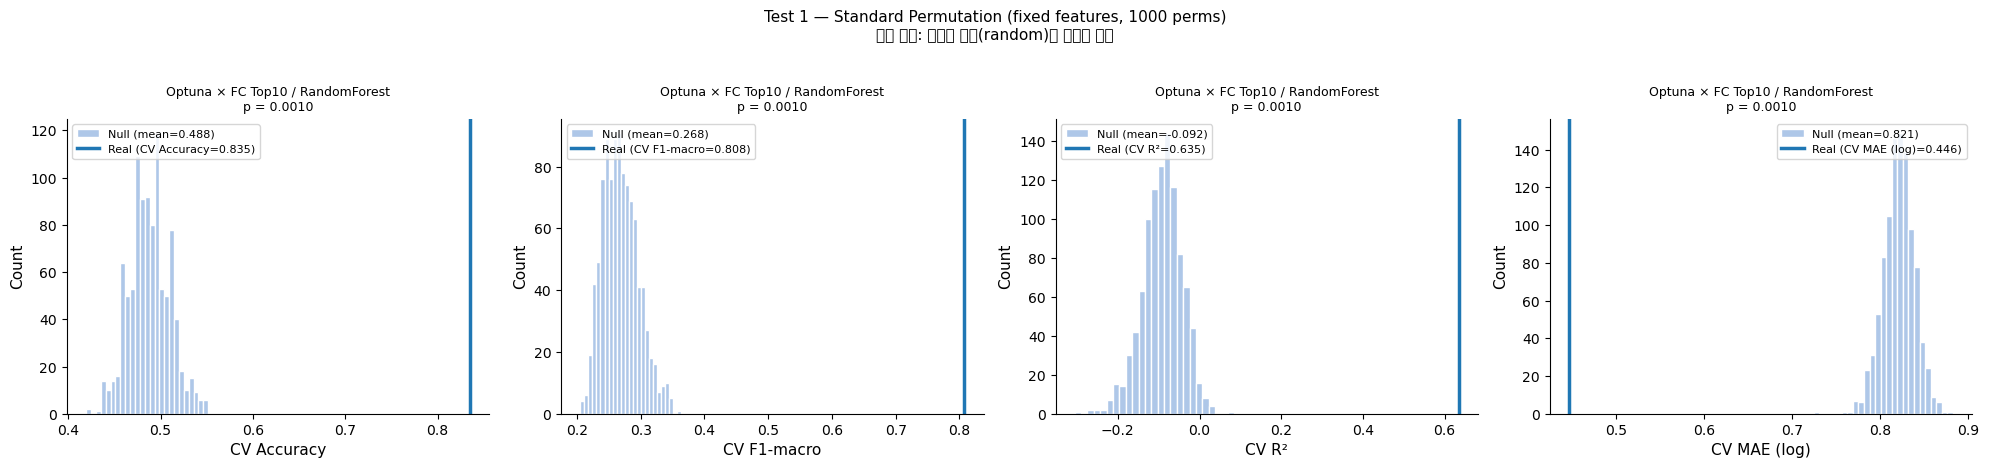

Saved: val_perm_test1_fixed.png


/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig2.tight_layout()
/tmp/ipykernel_252149/981726550.py:208: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaV

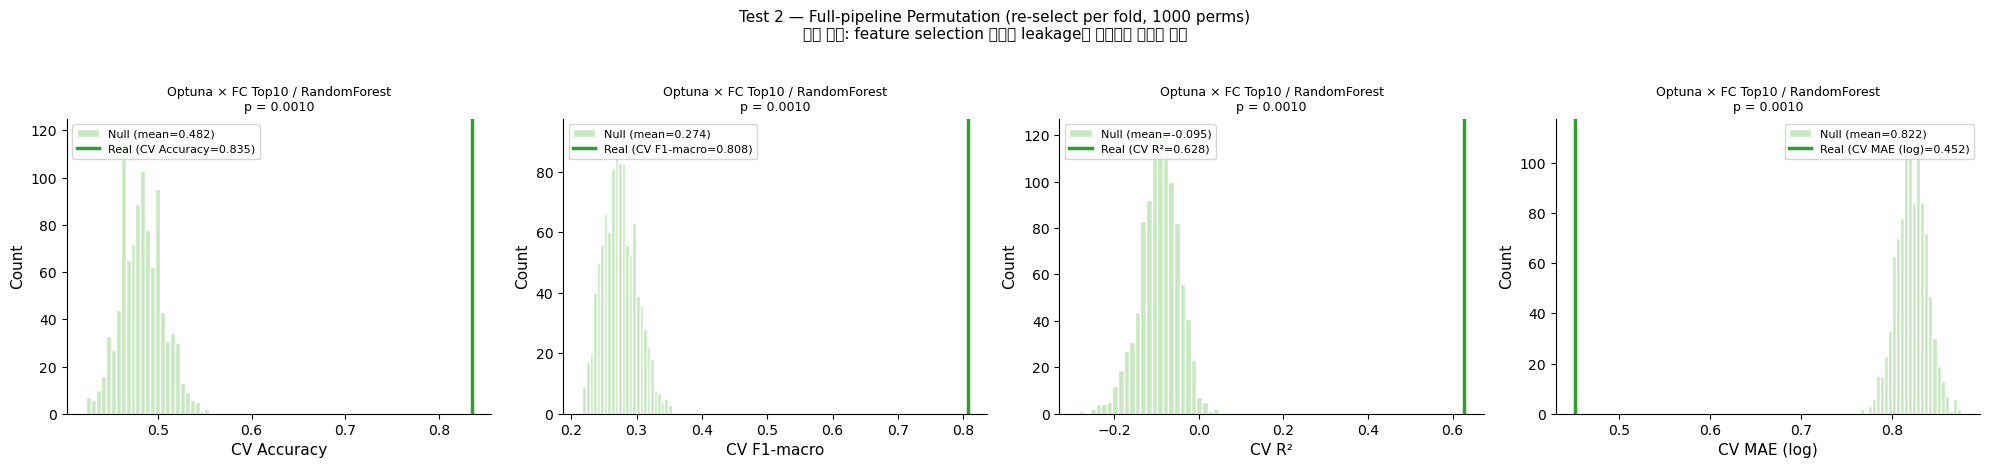

Saved: val_perm_test2_fullpipeline.png


/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig3.tight_layout()
/tmp/ipykernel_252149/981726550.py:242: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu San

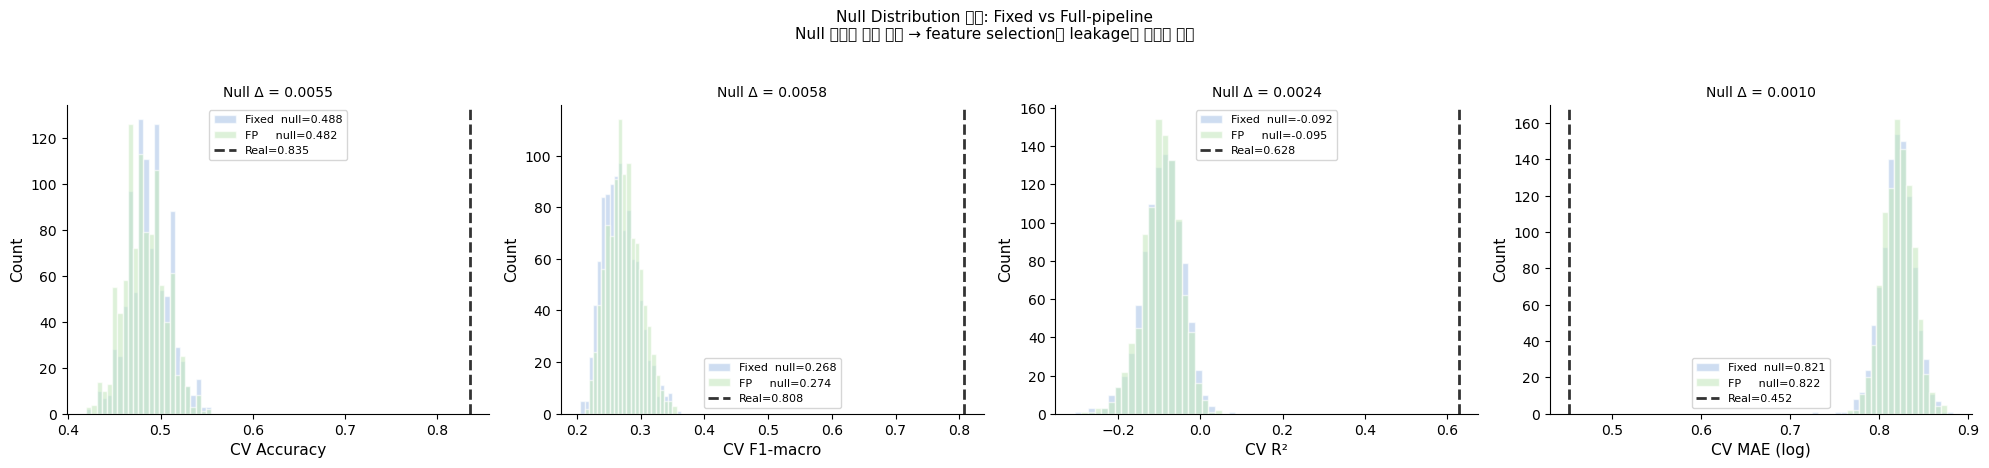

Saved: val_perm_null_comparison.png

=== Permutation Test Summary ===
지표             Fix Real   Fix Null    Fix p |  FP Real  FP Null     FP p |   Null Δ
Accuracy          0.835      0.488   0.0010 |    0.835    0.482   0.0010 |   0.0055
F1-macro          0.808      0.268   0.0010 |    0.808    0.274   0.0010 |   0.0058
R²                0.635     -0.092   0.0010 |    0.628   -0.095   0.0010 |   0.0024
MAE               0.446      0.821   0.0010 |    0.452    0.822   0.0010 |   0.0010


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.model_selection import StratifiedKFold, KFold

PKL_DIR    = "/home/admin-01/taeho/BRL_chicken/revision/code/data/pkl"
VAL_DIR    = "/home/admin-01/taeho/BRL_chicken/revision/code/data/val_figures"
LABEL_SEED = 42
N_PERM     = 1000
K_FOLDS    = 5
N_TOP      = 10

with open(f"{PKL_DIR}/best_model_pipeline.pkl", 'rb') as f:
    clf_pipe = pickle.load(f)
with open(f"{PKL_DIR}/best_reg_pipeline.pkl", 'rb') as f:
    reg_pipe = pickle.load(f)
with open(f"{PKL_DIR}/labeled_splits.pkl", 'rb') as f:
    d = pickle.load(f)
with open(f"{PKL_DIR}/screening_results.pkl", 'rb') as f:
    screen = pickle.load(f)

clf_model     = clf_pipe['model']
reg_model     = reg_pipe['model']
tpc_col       = reg_pipe['tpc_col']
all_feat_cols = screen['feature_cols']

sp     = d['labeled_splits'][LABEL_SEED]
df_all = pd.concat([sp['train'], sp['test']], axis=0).reset_index(drop=True)
df_fm  = df_all[df_all['Label'] != 1].reset_index(drop=True)

X_clf_full   = df_all[all_feat_cols].values
y_clf        = df_all['Label'].values
X_reg_full   = df_fm[all_feat_cols].values
y_reg        = df_fm[tpc_col].values
y_reg_labels = df_fm['Label'].values

clf_splits = list(StratifiedKFold(n_splits=K_FOLDS, shuffle=True,
                                  random_state=42).split(X_clf_full, y_clf))
reg_splits = list(KFold(n_splits=K_FOLDS, shuffle=True,
                        random_state=42).split(X_reg_full))

clf_label = f"{clf_pipe['cond_label']} / {clf_pipe['model_name']}"
reg_label = f"{reg_pipe['cond_label']} / {reg_pipe['model_name']}"

# ── 헬퍼: FC Top-N 선택 ────────────────────────────────────────────
def select_fc_topn(X_tr, y_tr, n_top=N_TOP):
    classes = np.unique(y_tr)
    if len(classes) < 2:
        return np.arange(n_top)
    means    = [X_tr[y_tr == c].mean(axis=0) for c in classes]
    max_diff = np.zeros(X_tr.shape[1])
    for i in range(len(means)):
        for j in range(i + 1, len(means)):
            max_diff = np.maximum(max_diff, np.abs(means[i] - means[j]))
    return np.argsort(max_diff)[::-1][:n_top]

# ── Test 1: 고정 피처 함수 ─────────────────────────────────────────
def run_fix_clf(X_fix, y, splits):
    accs, f1s = [], []
    for tr, te in splits:
        m  = clone(clf_model).fit(X_fix[tr], y[tr])
        yp = m.predict(X_fix[te])
        accs.append(accuracy_score(y[te], yp))
        f1s.append(f1_score(y[te], yp, average='macro'))
    return np.mean(accs), np.mean(f1s)

def run_fix_reg(X_fix, y_r, splits):
    r2s, maes = [], []
    for tr, te in splits:
        m  = clone(reg_model).fit(X_fix[tr], y_r[tr])
        yp = m.predict(X_fix[te])
        r2s.append(r2_score(y_r[te], yp))
        maes.append(np.mean(np.abs(y_r[te] - yp)))
    return np.mean(r2s), np.mean(maes)

# ── Test 2: Full-pipeline 함수 ─────────────────────────────────────
def run_fp_clf(X_full, y, splits):
    accs, f1s = [], []
    for tr, te in splits:
        idx = select_fc_topn(X_full[tr], y[tr])
        m   = clone(clf_model).fit(X_full[tr][:, idx], y[tr])
        yp  = m.predict(X_full[te][:, idx])
        accs.append(accuracy_score(y[te], yp))
        f1s.append(f1_score(y[te], yp, average='macro'))
    return np.mean(accs), np.mean(f1s)

def run_fp_reg(X_full, y_r, y_labels, splits):
    r2s, maes = [], []
    for tr, te in splits:
        idx = select_fc_topn(X_full[tr], y_labels[tr])
        m   = clone(reg_model).fit(X_full[tr][:, idx], y_r[tr])
        yp  = m.predict(X_full[te][:, idx])
        r2s.append(r2_score(y_r[te], yp))
        maes.append(np.mean(np.abs(y_r[te] - yp)))
    return np.mean(r2s), np.mean(maes)

# ── Test 1 Setup: 전체 데이터에서 피처 1회 고정 ───────────────────
clf_idx_fix = select_fc_topn(X_clf_full, y_clf)
reg_idx_fix = select_fc_topn(X_reg_full, y_reg_labels)
X_clf_fix   = X_clf_full[:, clf_idx_fix]
X_reg_fix   = X_reg_full[:, reg_idx_fix]

# ── Real scores ────────────────────────────────────────────────────
real_acc_fix, real_f1_fix             = run_fix_clf(X_clf_fix, y_clf, clf_splits)
real_r2_fix,  real_mae_fix            = run_fix_reg(X_reg_fix, y_reg, reg_splits)
real_acc_fp,  real_f1_fp              = run_fp_clf(X_clf_full, y_clf, clf_splits)
real_r2_fp,   real_mae_fp            = run_fp_reg(X_reg_full, y_reg, y_reg_labels, reg_splits)

print(f"[Test 1 Fixed]  Acc={real_acc_fix:.3f}  F1={real_f1_fix:.3f}  "
      f"R²={real_r2_fix:.3f}  MAE={real_mae_fix:.3f}")
print(f"[Test 2 FP   ]  Acc={real_acc_fp:.3f}   F1={real_f1_fp:.3f}   "
      f"R²={real_r2_fp:.3f}  MAE={real_mae_fp:.3f}")

# ── Permutation loop (동일 치환 시퀀스 공유) ──────────────────────
rng = np.random.default_rng(42)
perm_acc_fix, perm_f1_fix, perm_r2_fix, perm_mae_fix = [], [], [], []
perm_acc_fp,  perm_f1_fp,  perm_r2_fp,  perm_mae_fp  = [], [], [], []

for i in range(N_PERM):
    py_clf        = rng.permutation(y_clf)
    py_reg        = rng.permutation(y_reg)
    py_reg_labels = y_reg_labels[np.argsort(np.argsort(py_reg))]

    a1, f1_ = run_fix_clf(X_clf_fix, py_clf, clf_splits)
    r1, m1  = run_fix_reg(X_reg_fix, py_reg, reg_splits)
    perm_acc_fix.append(a1); perm_f1_fix.append(f1_)
    perm_r2_fix.append(r1);  perm_mae_fix.append(m1)

    a2, f2_ = run_fp_clf(X_clf_full, py_clf, clf_splits)
    r2_, m2 = run_fp_reg(X_reg_full, py_reg, py_reg_labels, reg_splits)
    perm_acc_fp.append(a2); perm_f1_fp.append(f2_)
    perm_r2_fp.append(r2_);  perm_mae_fp.append(m2)

    if (i + 1) % 100 == 0:
        print(f"[{i+1}/{N_PERM}] Fix: acc={a1:.3f} r2={r1:.3f} | "
              f"FP: acc={a2:.3f} r2={r2_:.3f}")

perm_acc_fix = np.array(perm_acc_fix); perm_f1_fix = np.array(perm_f1_fix)
perm_r2_fix  = np.array(perm_r2_fix);  perm_mae_fix = np.array(perm_mae_fix)
perm_acc_fp  = np.array(perm_acc_fp);  perm_f1_fp  = np.array(perm_f1_fp)
perm_r2_fp   = np.array(perm_r2_fp);   perm_mae_fp  = np.array(perm_mae_fp)

def pval(perm, real): return (np.sum(perm >= real) + 1) / (N_PERM + 1)

p_acc_fix = pval(perm_acc_fix, real_acc_fix); p_f1_fix = pval(perm_f1_fix, real_f1_fix)
p_r2_fix  = pval(perm_r2_fix,  real_r2_fix);  p_mae_fix = pval(-perm_mae_fix, -real_mae_fix)
p_acc_fp  = pval(perm_acc_fp,  real_acc_fp);  p_f1_fp  = pval(perm_f1_fp,  real_f1_fp)
p_r2_fp   = pval(perm_r2_fp,   real_r2_fp);   p_mae_fp  = pval(-perm_mae_fp, -real_mae_fp)

# ─────────────────────────────────────────────────────────────────
# Figure 1: Test 1 (고정 피처) — 4 metrics
# ─────────────────────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 4, figsize=(20, 4.5))
tasks1 = [
    (axes[0], perm_acc_fix, real_acc_fix, p_acc_fix, 'CV Accuracy',   clf_label, True),
    (axes[1], perm_f1_fix,  real_f1_fix,  p_f1_fix,  'CV F1-macro',   clf_label, True),
    (axes[2], perm_r2_fix,  real_r2_fix,  p_r2_fix,  'CV R²',         reg_label, True),
    (axes[3], perm_mae_fix, real_mae_fix, p_mae_fix, 'CV MAE (log)',   reg_label, False),
]
for ax, pv, rv, pv_p, metric, label, higher_better in tasks1:
    ax.hist(pv, bins=25, color='#aec7e8', edgecolor='white',
            label=f'Null (mean={pv.mean():.3f})')
    ax.axvline(rv, color='#1f77b4', lw=2.5,
               label=f'Real ({metric}={rv:.3f})')
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f"{label}\np = {pv_p:.4f}", fontsize=9)
    ax.legend(fontsize=8, loc='upper left' if higher_better else 'upper right')
    ax.spines[['top', 'right']].set_visible(False)

fig1.suptitle(
    f"Test 1 — Standard Permutation (fixed features, {N_PERM} perms)\n"
    f"검증 목적: 성능이 우연(random)이 아님을 확인",
    fontsize=11, y=1.03)
fig1.tight_layout()
fig1.savefig(f"{VAL_DIR}/val_perm_test1_fixed.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: val_perm_test1_fixed.png")

# ─────────────────────────────────────────────────────────────────
# Figure 2: Test 2 (Full-pipeline) — 4 metrics
# ─────────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 4, figsize=(20, 4.5))
tasks2 = [
    (axes[0], perm_acc_fp, real_acc_fp, p_acc_fp, 'CV Accuracy', clf_label, True),
    (axes[1], perm_f1_fp,  real_f1_fp,  p_f1_fp,  'CV F1-macro', clf_label, True),
    (axes[2], perm_r2_fp,  real_r2_fp,  p_r2_fp,  'CV R²',       reg_label, True),
    (axes[3], perm_mae_fp, real_mae_fp, p_mae_fp, 'CV MAE (log)', reg_label, False),
]
for ax, pv, rv, pv_p, metric, label, higher_better in tasks2:
    ax.hist(pv, bins=25, color='#c7e9c0', edgecolor='white',
            label=f'Null (mean={pv.mean():.3f})')
    ax.axvline(rv, color='#2ca02c', lw=2.5,
               label=f'Real ({metric}={rv:.3f})')
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f"{label}\np = {pv_p:.4f}", fontsize=9)
    ax.legend(fontsize=8, loc='upper left' if higher_better else 'upper right')
    ax.spines[['top', 'right']].set_visible(False)

fig2.suptitle(
    f"Test 2 — Full-pipeline Permutation (re-select per fold, {N_PERM} perms)\n"
    f"검증 목적: feature selection 자체가 leakage를 유발하지 않음을 확인",
    fontsize=11, y=1.03)
fig2.tight_layout()
fig2.savefig(f"{VAL_DIR}/val_perm_test2_fullpipeline.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: val_perm_test2_fullpipeline.png")

# ─────────────────────────────────────────────────────────────────
# Figure 3: Null distribution 비교 (동일 치환, 두 테스트 overlay)
# ─────────────────────────────────────────────────────────────────
fig3, axes = plt.subplots(1, 4, figsize=(20, 4.5))
compare = [
    (axes[0], perm_acc_fix, perm_acc_fp, real_acc_fp, 'CV Accuracy'),
    (axes[1], perm_f1_fix,  perm_f1_fp,  real_f1_fp,  'CV F1-macro'),
    (axes[2], perm_r2_fix,  perm_r2_fp,  real_r2_fp,  'CV R²'),
    (axes[3], perm_mae_fix, perm_mae_fp, real_mae_fp, 'CV MAE (log)'),
]
for ax, pv_fix, pv_fp, rv, metric in compare:
    bins = np.linspace(min(pv_fix.min(), pv_fp.min()),
                       max(pv_fix.max(), pv_fp.max()), 25)
    ax.hist(pv_fix, bins=bins, color='#aec7e8', alpha=0.6, edgecolor='white',
            label=f'Fixed  null={pv_fix.mean():.3f}')
    ax.hist(pv_fp,  bins=bins, color='#c7e9c0', alpha=0.6, edgecolor='white',
            label=f'FP     null={pv_fp.mean():.3f}')
    ax.axvline(rv, color='#333333', lw=2, linestyle='--', label=f'Real={rv:.3f}')
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    delta = abs(pv_fix.mean() - pv_fp.mean())
    ax.set_title(f"Null Δ = {delta:.4f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig3.suptitle(
    "Null Distribution 비교: Fixed vs Full-pipeline\n"
    "Null 분포가 거의 동일 → feature selection이 leakage를 만들지 않음",
    fontsize=11, y=1.03)
fig3.tight_layout()
fig3.savefig(f"{VAL_DIR}/val_perm_null_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: val_perm_null_comparison.png")

# ── 콘솔 요약 ─────────────────────────────────────────────────────
print("\n=== Permutation Test Summary ===")
print(f"{'지표':<12} {'Fix Real':>10} {'Fix Null':>10} {'Fix p':>8} | "
      f"{'FP Real':>8} {'FP Null':>8} {'FP p':>8} | {'Null Δ':>8}")
for metric, rv1, nv1, p1, rv2, nv2, p2 in [
    ('Accuracy',  real_acc_fix, perm_acc_fix.mean(), p_acc_fix,
                  real_acc_fp,  perm_acc_fp.mean(),  p_acc_fp),
    ('F1-macro',  real_f1_fix,  perm_f1_fix.mean(),  p_f1_fix,
                  real_f1_fp,   perm_f1_fp.mean(),   p_f1_fp),
    ('R²',        real_r2_fix,  perm_r2_fix.mean(),  p_r2_fix,
                  real_r2_fp,   perm_r2_fp.mean(),   p_r2_fp),
    ('MAE',       real_mae_fix, perm_mae_fix.mean(), p_mae_fix,
                  real_mae_fp,  perm_mae_fp.mean(),  p_mae_fp),
]:
    print(f"{metric:<12} {rv1:>10.3f} {nv1:>10.3f} {p1:>8.4f} | "
          f"{rv2:>8.3f} {nv2:>8.3f} {p2:>8.4f} | "
          f"{abs(nv1-nv2):>8.4f}")

## Permutation Test — Results and Interpretation

### Test 1 (Fixed features) — "Performance is not attributable to chance"

| Metric | Real model | Null mean | p |
|---|---|---|---|
| CV Accuracy | 0.835 | 0.488 | ≤ 0.001 |
| CV F1-macro | 0.808 | 0.268 | ≤ 0.001 |
| CV R²       | 0.635 | −0.092 | ≤ 0.001 |
| CV MAE      | 0.446 | 0.821 | ≤ 0.001 |

None of the 1,000 permutations exceeded the observed performance on any of the four metrics (p ≤ 0.001).  
→ Model performance is not attributable to random noise.

---

### Test 2 (Full-pipeline) — "Feature selection itself does not introduce leakage"

| Metric | Real model | Null mean | p | Δ from Test 1 null |
|---|---|---|---|---|
| CV Accuracy | 0.835 | 0.482 | ≤ 0.001 | 0.006 |
| CV F1-macro | 0.808 | 0.274 | ≤ 0.001 | 0.006 |
| CV R²       | 0.628 | −0.095 | ≤ 0.001 | 0.002 |
| CV MAE      | 0.452 | 0.822 | ≤ 0.001 | 0.001 |

Even with FC Top10 re-selected using permuted labels in every fold of every permutation, the null distribution remained virtually identical to that of Test 1 (Δ ≤ 0.006 across all metrics).  
→ **Directly confirms that the feature selection step itself does not introduce data leakage.**

---

### Null distribution interpretation

- **Null Accuracy ≈ 0.482–0.488**: Convergence to ~0.5 rather than the uniform 3-class expectation (0.333) is expected, as the higher proportion of Early samples means a majority-class strategy achieves above-chance accuracy → expected behavior
- **Null R² ≈ −0.092 to −0.095**: Regression on permuted labels performs worse than the mean predictor → expected behavior
- **Null MAE ≈ 0.821–0.822**: Large prediction error under randomized labels → expected behavior

---

### Key interpretation — Null distribution comparison

The difference between the two null distributions is negligible across all metrics (Δ ≤ 0.006).  
If feature selection were leaking test-set information, the full-pipeline null distribution would be **higher** — not lower — because feature selection would adapt to the permuted labels and produce some degree of artificial separation. The near-identical null distributions confirm that **feature selection improves performance only when a genuine feature–label relationship exists.**

Note: A slight reversal is observed for the F1 null (full-pipeline: 0.274 vs. fixed: 0.268). Re-selecting features using permuted labels per fold introduces noise into the feature set itself, marginally widening the null distribution — this is unrelated to leakage, and Δ = 0.006 falls within the range of sampling error.

---

> **Hyperparameter tuning is fixed based on the original labels**: A fully exhaustive pipeline would require re-running GridSearchCV at every permutation, which would demand upwards of five million model fits and is computationally infeasible.